# **MovieLens Movie Recommender**: scalable movie recommendation with Dask

<br>

In this tutorial, we'll build and compare several movie recommendation models using [Dask](https://www.dask.org/) and the [MovieLens 100K dataset](https://grouplens.org/datasets/movielens/100k/). We'll walk you through raw data files to a comparative analysis of recommendation models in a scalable Dask workflow with the following steps:
- Explore and process the 100K ratings dataset with Dask DataFrames.
- Implement and compare three collaborative filtering approaches: User-User, Item-Item, and Matrix Factorization (ALS).
- Build models using `dask-ml` for scalable machine learning.
- Evaluate model performance using Mean Squared Error (MSE).
- Compare and analyze the differences in recommendations generated by each model.

**Credits**

This tutorial is adapted from the course project: [CMU 11-637 Foundations of Computational Data Science](https://mcds-cmu.github.io/11637/m24/), *Project 2: Problem Representation*.


**Compatibility**

| Platform                     | Compatible | Recommended | Notes                                                                                                    |
| :--------------------------- | :--------: | :---------: | :------------------------------------------------------------------------------------------------------- |
| **Local (e.g., M1 MacBook)** |   ✅ Yes   |   ✅ Yes    | The 100K dataset is small and runs well locally. This setup is great for learning Dask's API.            |
| **Google Colab**             |   ✅ Yes   |   ⚠️ No    | The ALS algorithm runs slow on Colab machines with only 2 CPUs                                 |
| **Midway3 Login Node**       |   ✅ Yes   |    ✅ Yes    | Install Dask and run this on any login nodes. Dask will handle the Slurm job provisioning under the hood.                               |
| **Midway3 Compute Node**     |   ✅ Yes   |   ✅ Yes    | Ideal for this tutorial and for scaling up to larger datasets. Use `LocalCluster()` instead. |


## 🎬 The Dataset: MovieLens 100K

We will be working with the classic **MovieLens 100K Dataset**. It's a great size for learning—small enough to run quickly on a personal computer, but large enough to demonstrate the principles of scalable computing.

The dataset consists of:

- **100,000 ratings (1-5)**...
- from **943 users**...
- on **1,682 movies**.

The two main files are:

- `u.data`: Contains the ratings, with columns `user_id`, `item_id` (movie ID), `rating`, and `timestamp`.
- `u.item`: Contains metadata for each movie, including title and genres.


### Creating a Dask Slurm Cluster


In [ ]:
%pip install -q dask_jobqueue sparse

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 5.8 MB/s eta 0:00:00


In [ ]:
import os

from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster

In [ ]:
# Run this block if you are already on Colab or a Midway3 compute node
# cluster = LocalCluster()

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:38235
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42125'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43111'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36177 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36177
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43602
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42577 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42577
INFO:distributed.core:Starting established connection to tcp://127

In [ ]:
# Run this block if you are on Midway3 login node

# Create logging dir
os.makedirs("./logs", exist_ok=True)

SLURM_ACCOUNT = "macs40123"

# Compose SLURM script
cluster = SLURMCluster(
    queue="amd",
    cores=10,
    memory="60GB",
    processes=10,
    walltime="04:00:00",
    interface="ib0",
    job_extra_directives=[
        f"--account={SLURM_ACCOUNT}",
        "--output=logs/dask-%j.out",
        "--error=logs/dask-%j.err",
    ],
)

# Request resources
cluster.scale(jobs=1)

In [ ]:
client = Client(cluster)
client

INFO:distributed.scheduler:Receive client connection: Client-c82e1c32-ae3c-11f0-8252-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43640


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38235,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36177,Total threads: 1
Dashboard: http://127.0.0.1:36281/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:42125,


### Loading Data with Dask

We'll use `dask.dataframe.read_csv` to load the rating data in the `data` file to create a **Dask DataFrame**, which is similar to a Pandas DataFrame but operates lazily, allowing us to work with data that doesn't fit in memory.

The `movies` metadata file is quite small, so we'll load it with `Pandas.read_csv` to create a **Pandas dataframe** for easier lookups.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import dask
import dask.dataframe as dd
import dask.array as da
from scipy.sparse import coo_matrix

In [ ]:
# Run this block to download the dataset if you're running this as a standalone Colab notebook
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip ml-100k.zip

In [ ]:
# Load the user-ratings data using Dask
# A Dask DataFrame is a collection of smaller Pandas DataFrames
DATA_DIR = "./ml-100k"

ratings_dd = dd.read_csv(
    os.path.join(DATA_DIR, "u.data"),
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
)

# Persist the dataset to avoid reloading in the following three processing approaches
ratings_dd.persist()

print("A peek at the Dask ratings DataFrame:")
display(ratings_dd.head())

A peek at the Dask ratings DataFrame:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
# Load the movie metadata using Pandas (it's small)
movie_cols = [
    "movie_id",
    "movie_title",
    "release_date",
    "video_release_date",
    "IMDb_URL",
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]

genres = movie_cols[movie_cols.index("Action") :]
movies = pd.read_csv(
    os.path.join(DATA_DIR, "u.item"),
    sep="|",
    names=movie_cols,
    index_col="movie_id",
    encoding="ISO-8859-1",
)

movies.head()

,movie_title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie_id,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


---

## Data Exploration with Dask

A key concept in Dask is **lazy evaluation**. When we perform an operation on a Dask DataFrame, Dask builds a task graph but doesn't execute it immediately, and it will wait until we call the `.compute()` method. This allows Dask to optimize the entire sequence of steps before running anything.

### What are the average ratings by genre?

Let's calculate the average rating for each movie genre. Since a movie can belong to multiple genres, its rating should be calculated for each applicable genre. We will first "unpivot" or "melt" the `movies` DataFrame so that each row represents one movie and one genre, then we will merge this with the ratings data.


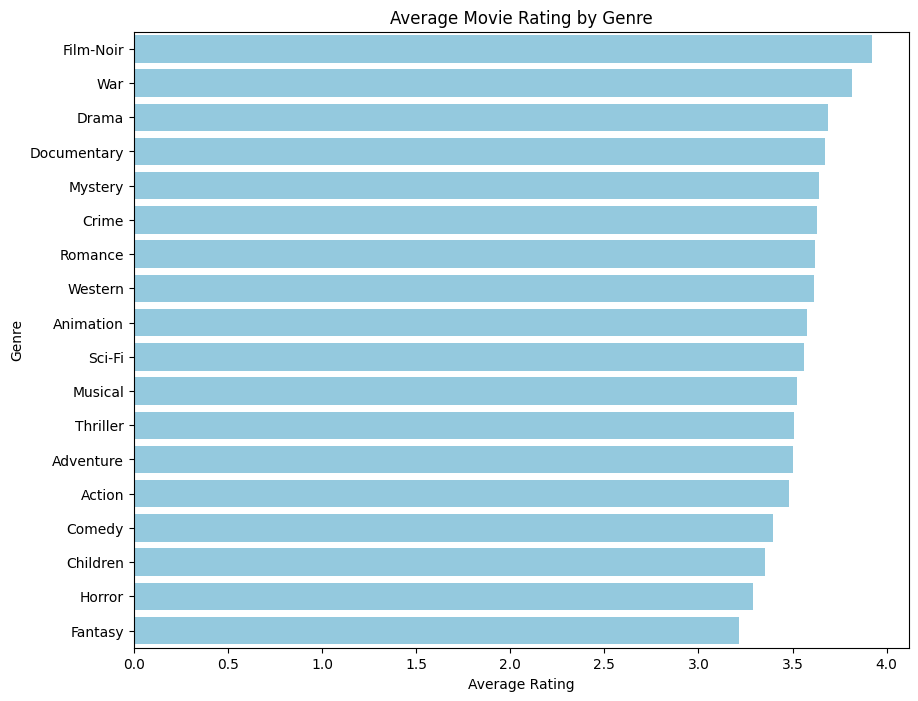

In [ ]:
# Melt the movies DataFrame to a long format: (movie_id, genre)
genres_df = movies.reset_index()[["movie_id"] + genres]
genres_melted = genres_df.melt(
    id_vars="movie_id", value_vars=genres, var_name="genre", value_name="is_genre"
)

# Filter for rows where the movie is in that genre
genres_melted = genres_melted[genres_melted["is_genre"] == 1][["movie_id", "genre"]]

# Merge the Dask ratings DataFrame with our genre information
merged_dd = ratings_dd.merge(genres_melted, left_on="item_id", right_on="movie_id")

# Now, group by genre and calculate the mean rating.
# This builds the task graph...
avg_genre_rating_dd = merged_dd.groupby("genre")["rating"].mean()

# ...and this executes it!
avg_genre_rating = avg_genre_rating_dd.compute().sort_values(ascending=False)


# Plotting the results
plt.figure(figsize=(10, 8))
sns.barplot(
    x=avg_genre_rating.values, y=avg_genre_rating.index, orient="h", color="skyblue"
)
plt.title("Average Movie Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

**Film-Noir**, **War**, and **Mystery** come out on top, while **Fantasy** and **Children's** movies have slightly lower average ratings.

### What are the best and worst movies?

Let's identify movies with the highest and lowest average ratings. We'll only consider those that have **more than 50 ratings**, excluding movies with just a few exceptionally high or low reviews.

With Dask, we can perform multiple aggregations at once using `groupby().agg()`.


In [ ]:
# Group by movie ID and calculate both the count and mean of ratings
movie_stats_dd = ratings_dd.groupby("item_id").agg({"rating": ["mean", "count"]})

# Flatten the multi-level columns
movie_stats_dd.columns = ["rating_mean", "rating_count"]

# Filter for movies with more than 50 ratings
popular_movies_dd = movie_stats_dd[movie_stats_dd["rating_count"] > 50]

# Trigger computation to get the results as a Pandas DataFrame
popular_movies = popular_movies_dd.compute()

# Add movie titles for context
popular_movies_with_titles = popular_movies.join(movies["movie_title"])

# Find the top 10 best and worst
best_movies = popular_movies_with_titles.sort_values(
    "rating_mean", ascending=False
).head(10)
worst_movies = popular_movies_with_titles.sort_values(
    "rating_mean", ascending=True
).head(10)

print("Top 10 Best-Rated Popular Movies:")
display(best_movies)

print("Top 10 Worst-Rated Popular Movies:")
display(worst_movies)

Top 10 Best-Rated Popular Movies:


,rating_mean,rating_count,movie_title
item_id,,,
408,4.491071,112,"Close Shave, A (1995)"
318,4.466443,298,Schindler's List (1993)
169,4.466102,118,"Wrong Trousers, The (1993)"
483,4.456790,243,Casablanca (1942)
114,4.447761,67,Wallace & Gromit: The Best of Aardman Animatio...
64,4.445230,283,"Shawshank Redemption, The (1994)"
603,4.387560,209,Rear Window (1954)
12,4.385768,267,"Usual Suspects, The (1995)"
50,4.358491,583,Star Wars (1977)


Top 10 Worst-Rated Popular Movies:


,rating_mean,rating_count,movie_title
item_id,,,
931,2.157895,57,"Island of Dr. Moreau, The (1996)"
687,2.188406,69,McHale's Navy (1997)
120,2.238806,67,Striptease (1996)
988,2.313953,86,"Beautician and the Beast, The (1997)"
122,2.339623,106,"Cable Guy, The (1996)"
450,2.396825,63,Star Trek V: The Final Frontier (1989)
412,2.397849,93,"Very Brady Sequel, A (1996)"
871,2.400000,75,Vegas Vacation (1997)
243,2.439394,132,Jungle2Jungle (1997)


It appears that classics like _The Shawshank Redemption_ and _Star Wars_ are universally loved, while some sequels and niche movies received a mixed response from audiences.

---


## Building the Recommender

Now for the main event. We will implement and compare three collaborative filtering algorithms to predict movie ratings. Given user $i$ and movie $j$, our goal is to predict the rating $\hat X_{ij}$.

To do this in a scalable way, we will avoid converting our entire dataset to a dense NumPy array. Instead, we'll represent the user-item ratings as a **sparse Dask Array**.

### Why Use a Sparse Matrix? The Power of Empty Space

In recommender systems, the user-item interaction matrix is almost always **sparse**. This means most users have rated only a tiny fraction of the available items.

Let's look at our MovieLens 100K dataset:
* **Total Possible Ratings:** 943 users × 1682 movies = 1,586,126
* **Actual Ratings Given:** 100,000

This means that only $100,000 \div 1,586,126 \approx 6.3\%$ of the matrix contains data, and over **93% of the matrix is empty space (zeros)!**

Using a sparse matrix provides two advantages:
1.  **Memory Efficiency:** Instead of storing all ~1.6 million numbers, a sparse matrix only stores the 100,000 actual ratings and their locations (`row`, `column`). This dramatically reduces the memory footprint.
2.  **Computational Speed:** Mathematical operations can be designed to skip calculations involving zeros. For example, when multiplying matrices, any multiplication by zero is skipped, leading to huge performance gains.

### How Dask Handles Sparsity: Backends and Formats

It's important to understand that Dask is a **parallel scheduler**, not a numerical library. It doesn't have its own sparse matrix implementation. Instead, it wraps other libraries and parallelizes their operations.

When you create a sparse Dask Array, you're creating a large, virtual array that is composed of many smaller chunks. Each of these chunks is an actual sparse matrix object from a **backend library**, such as:
* [**`scipy.sparse`**](https://docs.scipy.org/doc/scipy/reference/sparse.html): The long-standing, robust standard for sparse matrices in Python.
* [**`sparse`**](https://sparse.pydata.org/en/stable/introduction/): A newer library designed specifically for N-dimensional sparse arrays that integrates very cleanly with Dask. You will see the backend `sparse.numba_backend._coo.core.COO` in this notebook, indicating the usage of the `sparse` matrix backend.

These backends have different internal **formats**. Think of them like different ways of storing the same information:
* **COO (Coordinate format)**: A simple list of `(row, column, value)` tuples. It's excellent for building a matrix from scratch.
* **CSR (Compressed Sparse Row)**: A format that is highly optimized for fast row slicing and matrix arithmetic.

In our workflow, we will build the matrix using the COO format and then convert it to a format like CSR that is efficient for the parallel computations Dask will perform whenever needed.

---

### Data Preparation: Creating a Sparse Dask Array

First, we need to transform our data into a format that can be used to build the sparse array. This involves two steps:

1.  **Map IDs to Indices**: The `user_id` and `item_id` values are not necessarily zero-based or consecutive. We'll map them to continuous integer indices (0, 1, 2, ...) which will serve as the rows and columns of our matrix.
2.  **Construct the Array**: We'll use the mapped indices and the rating values to create a sparse matrix object from a backend library and then wrap it in a chunked Dask Array.

In [ ]:
# 1. Map IDs to continuous integer indices
# This creates a new column 'user_idx' with values from 0 to num_users-1
# And also a new column 'item_idx' for movie indices
ratings_dd = ratings_dd.assign(
    user_idx=ratings_dd["user_id"].astype("category").cat.as_known().cat.codes,
    item_idx=ratings_dd["item_id"].astype("category").cat.as_known().cat.codes,
)

# We need the dimensions of our matrix: number of unique users and items
n_users, n_items = dask.compute(
    ratings_dd["user_idx"].max() + 1,
    ratings_dd["item_idx"].max() + 1,
)

In [ ]:
import sparse as sp
import dask.array as da

# 2. Construct the Sparse Array
# Get the coordinates and data for the sparse array
ratings = ratings_dd[["user_idx", "item_idx", "rating"]].compute()

# Create a sparse.COO array using `sparse.COO(coords, data, shape)`
X_sparse = sp.COO(
    (ratings["user_idx"], ratings["item_idx"]),  # A tuple of coordinate arrays
    ratings["rating"],  # The data array
    shape=(n_users, n_items),
)

# Convert the sparse.COO array directly into a chunked Dask Array.
X_da = da.from_array(X_sparse, chunks=(500, 500))

print(
    f"Created a sparse Dask Array with shape {X_da.shape} and {X_da.npartitions} partitions."
)

Created a sparse Dask Array with shape (943, 1682) and 8 partitions.


---


### Approach 1: User-User Collaborative Filtering

**The Idea**: To predict how a user will rate a movie, find other users who have rated things similarly in the past. The prediction is a weighted average of how these "neighbor" users rated that same movie.

**The Math**: The predicted rating $\hat X_{ij}$ for user $i$ and movie $j$ is:

$$\hat X_{ij} = \bar x_i + \frac{  \sum_{k=1}^m w_{ik}(\mathbb{1}(X_{kj} \ne 0) \cdot (X_{kj} - \bar x_k))}{ \epsilon + \sum_{k=1}^m \mathbb{1}(X_{kj} \ne 0) \cdot |w_{ik}|}$$

Where

- $\bar x_i$ is the average rating given by user $i$.
- $w_{ik}$ is the similarity weight (e.g., cosine similarity) between user $i$ and user $k$.
- $X_{kj}$ is the actual rating user $k$ gave to movie $j$.

Note that we add a smoothing constant $\epsilon$ in the denominator to cover the case where no user has previously rated the movie $j$.

**Scalable Implementation**: All calculations will be performed with our sparse Dask Array, `X_da`. Dask will build a graph of these array operations and execute them in parallel without ever needing to hold the full dense matrix in memory.

#### Step 1: Calculate User Similarity ($w_{ik}$)

First, we define a function to compute the Cosine Similarity between all pairs of users. This will produce our weight matrix, $W$.

$$W_{ik}=\frac{\text{dot}(u_i, u_k)}{\|u_i\| \cdot \|u_k\|} = \frac{\sum_{j=1}^{n}X_{ij} X_{kj}}{\sqrt{\sum_{j=1}^{n}{X_{ij}}^2}\sqrt{\sum_{j=1}^{n}{X_{kj}}^2}}$$

In [ ]:
def cosine_similarity(matrix, eps=1e-9):
    """Computes cosine similarity between rows of a Dask Array."""
    # Compute squared norms row-wise: sum of squares along axis=1
    squared_norms = (matrix * matrix).sum(axis=1)

    # Take square root to get Euclidean norms
    norms = da.sqrt(squared_norms)
    norms = norms[:, None]
    norms = da.where(norms == 0, eps, norms)

    # Cosine similarity is dot product of normalized rows
    normalized = matrix / norms
    return normalized @ normalized.T

# Lazily compute the (n_users, n_users) similarity matrix
W_user_da = cosine_similarity(X_da)

W_user_da

dask.array<_chunk_sum-aggregate, shape=(943, 943), dtype=float64, chunksize=(500, 500), chunktype=sparse.COO>

#### Step 2: Center the Ratings Data ($X_{kj} - \bar x_k$)

Next, we calculate the average rating for each user ($\bar x_k$). Subtracting this mean from the actual ratings is called **centering**. This crucial step accounts for user bias. For example, it treats a 4-star rating from a harsh critic (who rarely gives high scores) as more significant than a 4-star rating from a user who gives 4s and 5s to everything.

In [ ]:
# Define the lazy calculations for user and movie means
user_means = ratings_dd.groupby("user_idx")["rating"].mean().compute().values
user_means_sparse = da.from_array(sp.COO(user_means.reshape(-1, 1)))

# Lazily subtract the mean rating from each user's rating vector
X_centered_da = X_da - user_means_sparse
X_centered_da = X_centered_da * (X_da != 0) # Apply mask to keep the matrix sparse

X_centered_da

dask.array<mul, shape=(943, 1682), dtype=float64, chunksize=(500, 500), chunktype=sparse.COO>

#### Step 3: Build the Prediction Formula ($\hat X_{ij}$)

Now we assemble the remaining pieces of the formula using our computed components.

In [ ]:
# Calculate the weighted sum of ratings (the numerator)
numerator_da = W_user_da @ X_centered_da

# Calculate the sum of absolute weights (the denominator)
denominator_da = da.fabs(W_user_da) @ (X_da != 0)

# Make the final prediction by adding the mean back to the weighted average.
# The entire graph is now defined, ready for computation.
X_pred_user = user_means_sparse + numerator_da / (denominator_da + 1e-9)

X_pred_user

dask.array<add, shape=(943, 1682), dtype=float64, chunksize=(500, 500), chunktype=sparse.COO>

With our lazy prediction matrix `X_pred_user_da` defined, we can now use it to generate concrete recommendations. The following function encapsulates the logic to find the top-K unseen movies for any given user.


In [ ]:
def get_top_k_recommendations(pred, user_idx, k=10):
    """Computes and formats the top-k recommendations for a given user."""
    # Compute the predicted ratings only for our user of interest
    # Convert to dense array to allow masking and argsorting
    user_preds = pred[user_idx].compute()
    if hasattr(user_preds, "todense"):
        user_preds = user_preds.todense()

    # Find which items the user has already rated
    rated_items = ratings_dd[ratings_dd["user_idx"] == user_idx]["item_idx"].compute().to_numpy()

    # Mask out already-rated items so we don't recommend them
    user_preds[rated_items] = -np.inf

    # Efficiently find the indices of the top k items
    topk_indices = np.argpartition(-user_preds, k - 1)[:k]
    # Sort just the top-k results to get the correct ranking
    topk_indices = topk_indices[np.argsort(-user_preds[topk_indices])]

    topk_scores = user_preds[topk_indices]
    return topk_indices, topk_scores

# Create this mapping once to reuse it
item_mapping = ratings_dd[["item_idx", "item_id"]].drop_duplicates().compute().set_index("item_idx")

Let's generate recommendations for a random user!

In [ ]:
# Pick a random user
random_user_idx = 92
indices, scores = get_top_k_recommendations(X_pred_user, random_user_idx)

# Map the internal indices back to original movie IDs and then to titles
recommendation_ids = item_mapping.loc[indices]["item_id"]
recommendation_titles = movies.loc[recommendation_ids]["movie_title"]

# Display the final results
recommendations_df = pd.DataFrame({
    "Rank": range(1, len(indices) + 1),
    "Movie": recommendation_titles.values,
    "Predicted Score": scores,
})

print(f"✨ Top 10 Recommendations for User (Internal Index: {random_user_idx})")
display(recommendations_df)

✨ Top 10 Recommendations for User (Internal Index: 92)


,Rank,Movie,Predicted Score
0,1,"Great Day in Harlem, A (1994)",5.252516
1,2,"Boys, Les (1997)",5.227083
2,3,Santa with Muscles (1996),5.082719
3,4,Nénette et Boni (1996),5.062051
4,5,Aiqing wansui (1994),5.054626
5,6,Two or Three Things I Know About Her (1966),4.990886
6,7,Delta of Venus (1994),4.973188
7,8,"Saint of Fort Washington, The (1993)",4.822520
8,9,Someone Else's America (1995),4.768251
9,10,Some Mother's Son (1996),4.653888


**Note:** The predicted score can exceed 5 due to the mean score offsetting we adopted in the previous steps.

---



### Approach 2: Item-Item Collaborative Filtering

This approach flips the logic of the user-user method. Instead of finding similar users, we find similar **items**. The prediction of the user's rating for a movie is based on the weighted average of the user's ratings for other similar movies. This is often **preferred** in practice as item-to-item relationships are generally more stable than user tastes.

**The formula** is a transpose of the user-user equation, where we now use the **item's average rating** ($\bar x_j$) and **item-item similarity weights** ($w_{jk}$):

$$\hat X_{ij} = \bar x_i + \frac{  \sum_{k=1}^m w_{ik}(\mathbb{1}(X_{kj} \ne 0) \cdot (X_{kj} - \bar x_k))}{ \epsilon + \sum_{k=1}^m \mathbb{1}(X_{kj} \ne 0) \cdot |w_{ik}|}$$

In [ ]:
# 1. Prepare Item-Centric Data
# Compute the average rating for each item.
item_means = ratings_dd.groupby("item_idx")["rating"].mean().compute().values
item_means_sparse = da.from_array(sp.COO(item_means)) # This is a 1D row vector

# 2. Build the Item-Item Prediction Graph
# Calculate item-item similarity by transposing the ratings matrix.
W_item_da = cosine_similarity(X_da.T)

# Center the data by subtracting the item's average rating.
X_item_centered_da = X_da - item_means_sparse
X_item_centered_da = X_item_centered_da * (X_da != 0)

# Assemble the prediction formula (note the transposed multiplication order).
numerator_item_da = X_item_centered_da @ W_item_da
denominator_item_da = (X_da != 0) @ da.fabs(W_item_da)
X_pred_item = item_means_sparse + numerator_item_da / (denominator_item_da + 1e-9)

print("Item-Item prediction graph has been defined.")
X_pred_item

Item-Item prediction graph has been defined.


dask.array<add, shape=(943, 1682), dtype=float64, chunksize=(500, 500), chunktype=sparse.COO>

### Generating and Comparing Recommendations

We can now use our `get_top_k_recommendations` function with this new prediction matrix to see how the results differ for the same user.

In [ ]:
# Generate recommendations using the item-item model's predictions.
indices, scores = get_top_k_recommendations(X_pred_item, random_user_idx)

# Map indices to titles and display the results.
recommendation_ids = item_mapping.loc[indices]["item_id"]
recommendation_titles = movies.loc[recommendation_ids]["movie_title"]

recommendations_df = pd.DataFrame({
    "Rank": range(1, len(indices) + 1),
    "Movie": recommendation_titles.values,
    "Predicted Score": scores,
})

print(f"✨ Top 10 Item-Item Recommendations for User (Internal Index: {random_user_idx})")
display(recommendations_df)

✨ Top 10 Item-Item Recommendations for User (Internal Index: 92)


,Rank,Movie,Predicted Score
0,1,Entertaining Angels: The Dorothy Day Story (1996),6.152074
1,2,"Great Day in Harlem, A (1994)",5.244518
2,3,Prefontaine (1997),5.074774
3,4,Star Kid (1997),5.000000
4,5,Aiqing wansui (1994),4.933748
5,6,Santa with Muscles (1996),4.927561
6,7,"Saint of Fort Washington, The (1993)",4.882635
7,8,Someone Else's America (1995),4.687391
8,9,"Letter From Death Row, A (1998)",4.615819
9,10,They Made Me a Criminal (1939),4.587518


In our results, item–item filtering produced a wider score range and surfaced more niche recommendations (e.g., Entertaining Angels), while user–user filtering gave more consensus-based picks with compressed scores.

For User 92, half of the top-10 predicted movies overlapped (e.g., Great Day in Harlem, Santa with Muscles), but ranks and predicted scores differed slightly.

### Approach 3: Matrix Factorization with Alternating Least Squares (ALS)

Matrix Factorization is a powerful technique that goes beyond direct user or item comparisons. The core idea is to **decompose** the massive user-item ratings matrix ($X$) into two much smaller, "denser" matrices:

1.  A **user-feature matrix** ($U$), with a row for each user.
2.  An **item-feature matrix** ($V$), with a column for each item.

$$X \approx U \times V^T$$

This approach assumes there are hidden, or **latent features**, that explain why a user likes a movie. These features might represent concepts like "amount of comedy," "level of sci-fi," or "suitability for children." The goal of Matrix Factorization is to automatically learn these features from the rating patterns.

This method, particularly its variant, was a cornerstone of the winning solution in the famous **Netflix Prize**, a million-dollar competition that revolutionized the field of recommender systems.

The Challenge & The Solution: **Alternating Least Squares (ALS)**

Finding the optimal user-feature matrix ($U$) and item-feature matrix ($V$) simultaneously is a challenging mathematical problem.

✨✨ **The breakthrough of ALS is to simplify this by solving for one matrix at a time, while keeping the other fixed.**

Think of it like tuning two knobs on a machine to get the best output. Instead of turning both randomly, you hold one still while you find the best position for the other, then you switch.

The **Alternating Least Squares** algorithm works as follows:

1.  Initialize $U$ and $V$ with small random numbers.
2.  **Fix $U$** and solve for the best possible $V$. This step turns into a standard, solvable least squares regression problem.
3.  **Fix the new $V$** and solve for the best possible $U$. This is also now a simple least squares problem.
4.  **Repeat** steps 2 and 3 for a number of iterations. With each alternation, the combined error of $U \times V^T$ gets closer to the true ratings in $X$.

To put it in Math, we

1. Initialize $U \in \mathbb{R}^{m \times k}$ and $V \in \mathbb{R}^{k \times n}$ with values distributed normally. Here $m$ is the number of users, $n$ is the number of movies, and $k$ is the input number of features.
2. Repeat `n_iters` times:
    * Update the columns of $V$:
    $$v_{j} := \left(\lambda I + \sum_{X_{ij} \ne 0} u_i u_i^T \right)^{-1} \left( \sum_{X_{ij} \ne 0} u_i X_{ij} \right), \quad j = 1, \ldots, n$$
    * Update the rows of $U$:
    $$u_{i} := \left(\lambda I + \sum_{X_{ij} \ne 0} v_j v_j^T \right)^{-1} \left( \sum_{X_{ij} \ne 0} v_j^T X_{ij} \right), \quad i = 1, \ldots, m$$

**The Scalability Problem & The Dask Solution: `dask.delayed`**

A standard implementation of ALS would require a `for` loop to update each user vector and another `for` loop for each item vector. In Python, these loops are **sequential**, meaning they run one after another. For millions of users or items, this would be incredibly slow.

This is where `dask.delayed` provides a powerful solution for parallelization.

  * **Building a To-Do List:** Instead of executing the calculation for each user immediately, `dask.delayed` wraps it in a **lazy "promise"** or placeholder. The `for` loop runs instantly, not doing any real work but rather building a giant to-do list of these promises.
  * **Creating a Task Graph:** Dask assembles this list into a dependency graph, understanding that all the user-update tasks are independent of each other.
  * **Parallel Execution:** When we call `.compute()`, Dask's scheduler takes this graph and executes all the independent tasks (all 943 user updates, for example) **in parallel** across all available CPU cores.

This transforms a sequential-looking algorithm into a massively parallel computation, allowing it to scale to huge datasets.

In [ ]:
import dask
import dask.array as da
from dask.distributed import Client
from scipy.sparse import csc_matrix, csr_matrix
import numpy as np
from scipy import linalg as la


@dask.delayed
def solve_for_user_vector(i, V, X_csr, lam, k):
    """Solves for a single user's feature vector u_i."""
    # Extract the i-th row from the sparse matrix
    X_i_row = X_csr[i, :]

    # Get the indices of items rated by user i
    rated_item_indices = X_i_row.indices

    # If the user has not rated any items, return a zero vector
    if rated_item_indices.size == 0:
        return np.zeros(k)

    # Get the feature vectors for the items rated by this user
    V_rated = V[rated_item_indices, :]

    # Get the actual ratings given by this user
    ratings_i = X_i_row.data

    # Form the matrices for the linear system
    # A = (lambda * I) + (V_rated^T @ V_rated)
    A = (lam * np.eye(k)) + (V_rated.T @ V_rated)

    # B = V_rated^T @ ratings_i
    B = V_rated.T @ ratings_i

    return la.solve(A, B)


@dask.delayed
def solve_for_item_vector(j, U, X_csc, lam, k):
    """Solves for a single item's feature vector v_j."""
    # Extract the j-th column from the sparse matrix
    X_j_col = X_csc[:, j]

    # Get the indices of users who rated item j
    rating_user_indices = X_j_col.indices

    # If the item has no ratings, return a zero vector
    if rating_user_indices.size == 0:
        return np.zeros(k)

    # Get the feature vectors for the users who rated this item
    U_rating = U[rating_user_indices, :]

    # Get the actual ratings for this item
    ratings_j = X_j_col.data

    # Form the matrices for the linear system
    # A = (lambda * I) + (U_rating^T @ U_rating)
    A = (lam * np.eye(k)) + (U_rating.T @ U_rating)

    # B = U_rating^T @ ratings_j
    B = U_rating.T @ ratings_j

    return la.solve(A, B)


def als_dask_delayed(X_sparse, k, niters=5, lam=10.0, seed=0):
    """
    Factor a rating matrix using ALS, parallelized with Dask.delayed.
    """
    np.random.seed(seed)
    m, n = X_sparse.shape

    # For efficient row/column slicing inside the delayed functions
    X_csr = X_sparse.tocsr()
    X_csc = X_sparse.tocsc()

    # Initialize U and V as standard NumPy arrays
    U = np.random.normal(loc=0, scale=0.1, size=(m, k))
    V = np.random.normal(loc=0, scale=0.1, size=(n, k))

    for iter_num in range(niters):
        print(f"Starting iteration {iter_num + 1}/{niters}...")

        # --- Update V (item vectors) in parallel ---
        # 1. Create a list of delayed objects
        V_delayed_rows = [solve_for_item_vector(j, U, X_csc, lam, k) for j in range(n)]

        # 2. Convert each delayed object to a Dask array, providing shape and dtype
        V_dask_arrays = [
            da.from_delayed(v, shape=(k,), dtype=np.float64) for v in V_delayed_rows
        ]

        # 3. Stack the Dask arrays and compute the result for this iteration
        V = da.stack(V_dask_arrays).compute()

        # --- Update U (user vectors) in parallel (same pattern) ---
        U_delayed_rows = [solve_for_user_vector(i, V, X_csr, lam, k) for i in range(m)]
        U_dask_arrays = [
            da.from_delayed(u, shape=(k,), dtype=np.float64) for u in U_delayed_rows
        ]
        U = da.stack(U_dask_arrays).compute()

    # Convert final NumPy results to Dask arrays before returning
    U_da = da.from_array(U, chunks=(-1, k))
    V_da = da.from_array(V.T, chunks=(k, -1))

    return U_da, V_da

Now we can use this function to get our user and item feature matrices as Dask Arrays.


In [ ]:
# Assume X_sparse is our scipy.sparse.coo_matrix from before
# This computation can be distributed by Dask across multiple cores.
# This cell might take 5min+ to run on Colab
U_da, V_da = als_dask_delayed(X_sparse, k=15)

# The predicted matrix is their dot product. This is a lazy Dask operation.
X_pred_mf = U_da @ V_da

Starting iteration 1/5...
Starting iteration 2/5...


Exception ignored in: <bound method GCDiagnosis._gc_callback of <distributed.gc.GCDiagnosis object at 0x7f6d0e3e4f50>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/distributed/gc.py", line 203, in _gc_callback
  File "/usr/local/lib/python3.12/dist-packages/psutil/_common.py", line 480, in wrapper
  File "<string>", line 3, in raise_from
  File "/usr/local/lib/python3.12/dist-packages/psutil/_common.py", line 478, in wrapper
  File "/usr/local/lib/python3.12/dist-packages/psutil/__init__.py", line 1063, in memory_info
  File "/usr/local/lib/python3.12/dist-packages/psutil/_pslinux.py", line 1653, in wrapper
  File "/usr/local/lib/python3.12/dist-packages/psutil/_pslinux.py", line 1885, in memory_info
RecursionError: maximum recursion depth exceeded while calling a Python object
Exception ignored in sys.unraisablehook: <built-in function unraisablehook>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iost

Starting iteration 3/5...


Exception ignored in: <bound method GCDiagnosis._gc_callback of <distributed.gc.GCDiagnosis object at 0x7f6d0e3e4f50>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/distributed/gc.py", line 203, in _gc_callback
  File "/usr/local/lib/python3.12/dist-packages/psutil/_common.py", line 480, in wrapper
  File "<string>", line 3, in raise_from
  File "/usr/local/lib/python3.12/dist-packages/psutil/_common.py", line 478, in wrapper
  File "/usr/local/lib/python3.12/dist-packages/psutil/__init__.py", line 1063, in memory_info
  File "/usr/local/lib/python3.12/dist-packages/psutil/_pslinux.py", line 1653, in wrapper
  File "/usr/local/lib/python3.12/dist-packages/psutil/_pslinux.py", line 1885, in memory_info
RecursionError: maximum recursion depth exceeded while calling a Python object
Exception ignored in sys.unraisablehook: <built-in function unraisablehook>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iost

Starting iteration 4/5...
Starting iteration 5/5...


In [ ]:
X_pred_mf

dask.array<getitem, shape=(943, 1682), dtype=float64, chunksize=(943, 1682), chunktype=numpy.ndarray>

In [ ]:
# Generate recommendations using the item-item model's predictions.
indices, scores = get_top_k_recommendations(X_pred_mf, random_user_idx)

# Map indices to titles and display the results.
recommendation_ids = item_mapping.loc[indices]["item_id"]
recommendation_titles = movies.loc[recommendation_ids]["movie_title"]

recommendations_df = pd.DataFrame({
    "Rank": range(1, len(indices) + 1),
    "Movie": recommendation_titles.values,
    "Predicted Score": scores,
})

print(f"✨ Top 10 Matrix Factorization Recommendations for User (Internal Index: {random_user_idx})")
display(recommendations_df)

✨ Top 10 Matrix Factorization Recommendations for User (Internal Index: 92)


,Rank,Movie,Predicted Score
0,1,Titanic (1997),4.119392
1,2,Air Force One (1997),3.786759
2,3,Good Will Hunting (1997),3.694365
3,4,Star Wars (1977),3.683000
4,5,"Full Monty, The (1997)",3.536293
5,6,Contact (1997),3.497335
6,7,"Boot, Das (1981)",3.445280
7,8,Return of the Jedi (1983),3.403952
8,9,Fly Away Home (1996),3.401612
9,10,L.A. Confidential (1997),3.379734


Compared to the **item–item** and **user–user** results, the **matrix factorization** recommendations are very different, and that’s expected.

Matrix factorization isn’t matching to similar users or similar items directly; instead, it learns **latent factors** (hidden taste dimensions) that explain a user' previous ratings and the patterns in the whole dataset:

* The list is **dominated by well-known, high-quality mainstream hits** (*Titanic*, *Good Will Hunting*, *Star Wars*).
* Predicted scores are **lower overall** (max ≈ 4.12) because the model centers around the baseline rating behavior.
* It balances popularity with users' latent interests rather than direct similarity.

It’s less about similar users or movie titles, and more about **abstract taste matching** across the entire movie-user space.


---

## Evaluation

Now that we have prediction matrices from all three methods, let's evaluate and compare how well do they perform.

### Metric: Mean Squared Error (MSE)

We'll use Mean Squared Error (MSE) to measure the average squared difference between our predicted ratings and the actual, observed ratings. A lower MSE is better.

$$\text{MSE} = \frac{\sum_{X_{ij} \ne 0} (X_{ij} - \hat X_{ij})^2}{\text{Number of observed ratings}}$$


In [ ]:
def mse_observed(X_true, X_pred):
    # Make sure both are Dask arrays with identical chunks
    if not isinstance(X_true, da.Array):
        X_true = da.from_array(X_true, chunks="auto")

    if not isinstance(X_pred, da.Array):
        X_pred = da.from_array(X_pred, chunks=X_true.chunks)
    else:
        X_pred = X_pred.rechunk(X_true.chunks)

    # Optional: make shapes/chunks known
    X_true = X_true.compute_chunk_sizes()
    X_pred = X_pred.compute_chunk_sizes()

    mask = X_true != 0
    se = da.where(mask, (X_true - X_pred) ** 2, 0)
    return (se.sum() / mask.sum()).compute()

mse_user = mse_observed(X_da, X_pred_user)
mse_item = mse_observed(X_da, X_pred_item)
mse_mf   = mse_observed(X_da, X_pred_mf)

# Display results
results = pd.DataFrame(
    {
        "Approach": ["User-User", "Item-Item", "Matrix Factorization"],
        "Mean Squared Error (MSE)": [mse_user, mse_item, mse_mf],
    }
)

print("Model Performance Comparison:")
display(results)

Model Performance Comparison:


,Approach,Mean Squared Error (MSE)
0,User-User,0.799251
1,Item-Item,0.762923
2,Matrix Factorization,0.604985


It appears that **Matrix Factorization** has the lowest MSE. It's a more powerful model that can capture nuanced patterns in the data compared to the neighborhood-based methods. Item-item often outperforms user-user because item similarities are generally more stable than user tastes.

---

## Further reading on the Netflix Challenge

The winning entry for the Netflix Prize wasn't a single Matrix Factorization model but a sophisticated **ensemble**—a carefully weighted blend of over 100 different models—submitted by the team **BellKor's Pragmatic Chaos**.

However, the most powerful and influential component of their winning solution was an advanced variant of matrix factorization that went far beyond the basic concept.

### The Winning Formula: MF with Biases and Time

The core of the BellKor team's approach was a **regularized** matrix factorization model that incorporated several key enhancements over the basic formula.

**1. Biases (or Intercepts)**

This was the most critical addition. The model acknowledged that rating behavior is influenced by consistent biases:
* **Global Average ($\mu$):** The average rating across all movies and users (e.g., 3.7 stars).
* **User Bias ($b_u$):** Some users are consistently harsh critics and always rate lower than average, while others are easy graders. This term captures that individual user's tendency.
* **Item Bias ($b_i$):** Some movies are universally acclaimed and receive higher-than-average ratings, while others are critically panned. This term captures the movie's intrinsic popularity or quality.

The prediction formula was therefore expanded from the simple $p_u^T q_i$ to:

$\hat{r}_{ui} = \mu + b_u + b_i + p_u^T q_i$

This change alone accounted for a huge portion of the model's accuracy, as it allowed the latent factors ($p_u$ and $q_i$) to model the user's *true preference*, separate from their tendency to be a "hater" or "lover" of movies in general.

**2. Temporal Dynamics (The Time Factor)** ⏳

BellKor's key insight was that user preferences and movie perceptions are not static; they change over time. They incorporated several time-drifting variables:
* **User Biases Change ($b_{u(t)}$):** A user might become a harsher or more lenient critic over the years.
* **Item Biases Change ($b_{i(t)}$):** A movie's popularity can fade, or it might become a "cult classic" long after its release.
* **User Preferences Change ($p_{u(t)}$):** A user might go through a "sci-fi phase" for a few months before moving on to documentaries.

By modeling these effects, their system could capture nuances like a user's evolving taste, making the predictions far more accurate.

### **Beyond a Single Model: The Power of Ensembling**

Ultimately, the prize was won by blending the predictions of many different models. No single algorithm was good enough on its own. The final model from BellKor's Pragmatic Chaos was a linear blend of over 100 predictors, including:
* Multiple versions of their advanced, time-aware matrix factorization models.
* Neighborhood models, similar to k-Nearest Neighbors (k-NN), which excel at capturing very specific local patterns.
* Restricted Boltzmann Machines (RBMs), a type of neural network.

This **ensemble method** is like asking a committee of diverse experts for their opinion and averaging the results. The collective wisdom of the group proved to be more accurate than any single expert.


## Conclusion

In this tutorial, we explored the fundamental pipeline of building scalable recommender systems. We explored how **Dask** and **Dask-ML** provide a familiar, Pandas-like API for tackling computations that are too large for a single machine's memory.

**Key Takeaways**:

- **Dask enables scalable data science** by parallelizing operations on DataFrames, Arrays and especially **Sparse Matrices**.
- **Item-Item Collaborative Filtering** is often a strong baseline, as item relationships are more static than user tastes.
- **Matrix Factorization** is a even more powerful technique that can uncover latent features, often leading to better accuracy and more personalized recommendations.

From here, you could try using a larger dataset (like the Netflix Dataset we used in our Wk1.3 Tutorial), tune the hyperparameters of the Matrix factorization model, add in item biases and temporal dynamics, or explore even more advanced deep learning-based recommender systems!
